In [ ]:
import json
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print('TensorFlow:', tf.__version__)


TensorFlow: 2.19.0


In [ ]:
# Optional: mount Google Drive to save outputs there.
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# If needed, clone the dataset.
!git clone https://github.com/jisharajr/Bharatanatyam-Mudra-Dataset.git


Cloning into 'Bharatanatyam-Mudra-Dataset'...
remote: Enumerating objects: 24938, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 24938 (delta 3), reused 1 (delta 0), pack-reused 24929 (from 1)
Receiving objects: 100% (24938/24938), 702.65 MiB | 40.38 MiB/s, done.
Resolving deltas: 100% (9/9), done.
Updating files: 100% (28433/28433), done.


In [ ]:
import os
import shutil

dataset_path = Path('/content/Bharatanatyam-Mudra-Dataset')

# Remove non-class items and clean names like '(1)'.
for item in os.listdir(dataset_path):
    item_path = dataset_path / item
    if item.startswith('.') or not item_path.is_dir():
        if item_path.is_dir():
            shutil.rmtree(item_path)
        elif item_path.exists():
            item_path.unlink()

for folder in list(os.listdir(dataset_path)):
    old_path = dataset_path / folder
    if old_path.is_dir():
        new_name = folder.replace('(1)', '').strip()
        new_path = dataset_path / new_name
        if old_path != new_path and not new_path.exists():
            os.rename(old_path, new_path)

class_folders = sorted([p.name for p in dataset_path.iterdir() if p.is_dir()])
print('Total classes:', len(class_folders))
print(class_folders)


Total classes: 50
['Alapadmam', 'Anjali', 'Aralam', 'Ardhachandran', 'Ardhapathaka', 'Berunda', 'Bramaram', 'Chakra', 'Chandrakala', 'Chaturam', 'Garuda', 'Hamsapaksha', 'Hamsasyam', 'Kangulam', 'Kapith', 'Kapotham', 'Karkatta', 'Kartariswastika', 'Katakamukha_1', 'Katakamukha_2', 'Katakamukha_3', 'Katakavardhana', 'Katrimukha', 'Khatva', 'Kilaka', 'Kurma', 'Matsya', 'Mayura', 'Mrigasirsha', 'Mukulam', 'Mushti', 'Nagabandha', 'Padmakosha', 'Pasha', 'Pathaka', 'Pushpaputa', 'Sakata', 'Samputa', 'Sarpasirsha', 'Shanka', 'Shivalinga', 'Shukatundam', 'Sikharam', 'Simhamukham', 'Suchi', 'Swastikam', 'Tamarachudam', 'Tripathaka', 'Trishulam', 'Varaha']


In [ ]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123
VAL_SPLIT = 0.2

OUTPUT_DIR = Path('/content/drive/MyDrive/mudra_mobilenetv2_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Outputs will be saved to:', OUTPUT_DIR)


Outputs will be saved to: /content/drive/MyDrive/mudra_mobilenetv2_outputs


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=VAL_SPLIT,
    subset='training',
    seed=SEED,
    color_mode='grayscale',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=VAL_SPLIT,
    subset='validation',
    seed=SEED,
    color_mode='grayscale',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = train_ds.class_names
num_classes = len(class_names)
print('Classes found:', num_classes)
print(class_names)

with open(OUTPUT_DIR / 'class_names.json', 'w', encoding='utf-8') as f:
    json.dump(class_names, f, indent=2)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)


Found 28431 files belonging to 50 classes.
Using 22745 files for training.
Found 28431 files belonging to 50 classes.
Using 5686 files for validation.
Classes found: 50
['Alapadmam', 'Anjali', 'Aralam', 'Ardhachandran', 'Ardhapathaka', 'Berunda', 'Bramaram', 'Chakra', 'Chandrakala', 'Chaturam', 'Garuda', 'Hamsapaksha', 'Hamsasyam', 'Kangulam', 'Kapith', 'Kapotham', 'Karkatta', 'Kartariswastika', 'Katakamukha_1', 'Katakamukha_2', 'Katakamukha_3', 'Katakavardhana', 'Katrimukha', 'Khatva', 'Kilaka', 'Kurma', 'Matsya', 'Mayura', 'Mrigasirsha', 'Mukulam', 'Mushti', 'Nagabandha', 'Padmakosha', 'Pasha', 'Pathaka', 'Pushpaputa', 'Sakata', 'Samputa', 'Sarpasirsha', 'Shanka', 'Shivalinga', 'Shukatundam', 'Sikharam', 'Simhamukham', 'Suchi', 'Swastikam', 'Tamarachudam', 'Tripathaka', 'Trishulam', 'Varaha']


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.12),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.15),
], name='augmentation')


In [ ]:
inputs = layers.Input(shape=(224, 224, 1))
x = data_augmentation(inputs)
x = layers.Concatenate()([x, x, x])
x = preprocess_input(x)

backbone = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
backbone.trainable = False

x = backbone(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.35)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs, name='mudra_mobilenetv2')
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mudra_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 224, 224,  │          0 │ augmentation[0][… │
│ (Concatenate)       │ 3)                │            │ augmentation[0][… │
│                     │                   │            │ augmentation[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide         │ (None, 224, 224,  │          0 │ concatenate[0][0] │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 224, 224,  │          0 │ true_divide[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ subtract[0][0]    │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1280)      │      5,120 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 50)        │     64,050 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,327,154 (8.88 MB)

 Trainable params: 66,610 (260.20 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
callbacks_stage1 = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7),
    tf.keras.callbacks.ModelCheckpoint(str(OUTPUT_DIR / 'best_head.keras'), monitor='val_accuracy', save_best_only=True),
]

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=callbacks_stage1,
)


Epoch 1/12
711/711 ━━━━━━━━━━━━━━━━━━━━ 69s 80ms/step - accuracy: 0.6543 - loss: 1.2427 - val_accuracy: 0.7897 - val_loss: 0.6813 - learning_rate: 0.0010
Epoch 2/12
711/711 ━━━━━━━━━━━━━━━━━━━━ 74s 77ms/step - accuracy: 0.8113 - loss: 0.6207 - val_accuracy: 0.7919 - val_loss: 0.6822 - learning_rate: 0.0010
Epoch 3/12
711/711 ━━━━━━━━━━━━━━━━━━━━ 82s 77ms/step - accuracy: 0.8360 - loss: 0.5419 - val_accuracy: 0.7937 - val_loss: 0.6878 - learning_rate: 0.0010
Epoch 4/12
711/711 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.8626 - loss: 0.4487 - val_accuracy: 0.8540 - val_loss: 0.4590 - learning_rate: 2.0000e-04
Epoch 5/12
711/711 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.8650 - loss: 0.4317 - val_accuracy: 0.8595 - val_loss: 0.4379 - learning_rate: 2.0000e-04
Epoch 6/12
711/711 ━━━━━━━━━━━━━━━━━━━━ 54s 77ms/step - accuracy: 0.8736 - loss: 0.4134 - val_accuracy: 0.8565 - val_loss: 0.4408 - learning_rate: 2.0000e-04
Epoch 7/12
711/711 ━━━━━━━━━━━━━━━━━━━━ 54s 76ms/step - accuracy

In [ ]:
# Fine-tuning stage.
backbone.trainable = True
fine_tune_at = 100
for layer in backbone.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_stage2 = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7),
    tf.keras.callbacks.ModelCheckpoint(str(OUTPUT_DIR / 'best_finetuned.keras'), monitor='val_accuracy', save_best_only=True),
]

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=22,
    initial_epoch=12,
    callbacks=callbacks_stage2,
)


Epoch 13/22
711/711 ━━━━━━━━━━━━━━━━━━━━ 98s 119ms/step - accuracy: 0.6816 - loss: 1.1127 - val_accuracy: 0.8491 - val_loss: 0.4529 - learning_rate: 1.0000e-05
Epoch 14/22
711/711 ━━━━━━━━━━━━━━━━━━━━ 144s 123ms/step - accuracy: 0.8269 - loss: 0.5568 - val_accuracy: 0.8568 - val_loss: 0.4189 - learning_rate: 1.0000e-05
Epoch 15/22
711/711 ━━━━━━━━━━━━━━━━━━━━ 86s 121ms/step - accuracy: 0.8729 - loss: 0.3987 - val_accuracy: 0.8801 - val_loss: 0.3474 - learning_rate: 1.0000e-05
Epoch 16/22
711/711 ━━━━━━━━━━━━━━━━━━━━ 86s 121ms/step - accuracy: 0.9014 - loss: 0.3077 - val_accuracy: 0.9110 - val_loss: 0.2681 - learning_rate: 1.0000e-05
Epoch 17/22
711/711 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.9192 - loss: 0.2414 - val_accuracy: 0.9272 - val_loss: 0.2182 - learning_rate: 1.0000e-05
Epoch 18/22
711/711 ━━━━━━━━━━━━━━━━━━━━ 141s 120ms/step - accuracy: 0.9301 - loss: 0.2092 - val_accuracy: 0.9353 - val_loss: 0.1954 - learning_rate: 1.0000e-05
Epoch 19/22
711/711 ━━━━━━━━━━━━━━━━━━

In [ ]:
final_model_path = OUTPUT_DIR / 'mudra_mobilenetv2_final.keras'
model.save(final_model_path)
print('Saved final model to:', final_model_path)
print('Saved class names to:', OUTPUT_DIR / 'class_names.json')


Saved final model to: /content/drive/MyDrive/mudra_mobilenetv2_outputs/mudra_mobilenetv2_final.keras
Saved class names to: /content/drive/MyDrive/mudra_mobilenetv2_outputs/class_names.json


In [ ]:
# Optional evaluation block.
loss, accuracy = model.evaluate(val_ds)
print('Validation loss:', loss)
print('Validation accuracy:', accuracy)


178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.9634 - loss: 0.1197
Validation loss: 0.11972824484109879
Validation accuracy: 0.9634189009666443


Found 28431 files belonging to 50 classes.
Eval class names:
['Alapadmam', 'Anjali', 'Aralam', 'Ardhachandran', 'Ardhapathaka', 'Berunda', 'Bramaram', 'Chakra', 'Chandrakala', 'Chaturam', 'Garuda', 'Hamsapaksha', 'Hamsasyam', 'Kangulam', 'Kapith', 'Kapotham', 'Karkatta', 'Kartariswastika', 'Katakamukha_1', 'Katakamukha_2', 'Katakamukha_3', 'Katakavardhana', 'Katrimukha', 'Khatva', 'Kilaka', 'Kurma', 'Matsya', 'Mayura', 'Mrigasirsha', 'Mukulam', 'Mushti', 'Nagabandha', 'Padmakosha', 'Pasha', 'Pathaka', 'Pushpaputa', 'Sakata', 'Samputa', 'Sarpasirsha', 'Shanka', 'Shivalinga', 'Shukatundam', 'Sikharam', 'Simhamukham', 'Suchi', 'Swastikam', 'Tamarachudam', 'Tripathaka', 'Trishulam', 'Varaha']
889/889 ━━━━━━━━━━━━━━━━━━━━ 53s 60ms/step

Classification Report:

                 precision    recall  f1-score   support

      Alapadmam     0.9852    0.9926    0.9889       537
         Anjali     0.9642    0.9528    0.9584       593
         Aralam     0.9507    0.9398    0.9452       615
  Ard

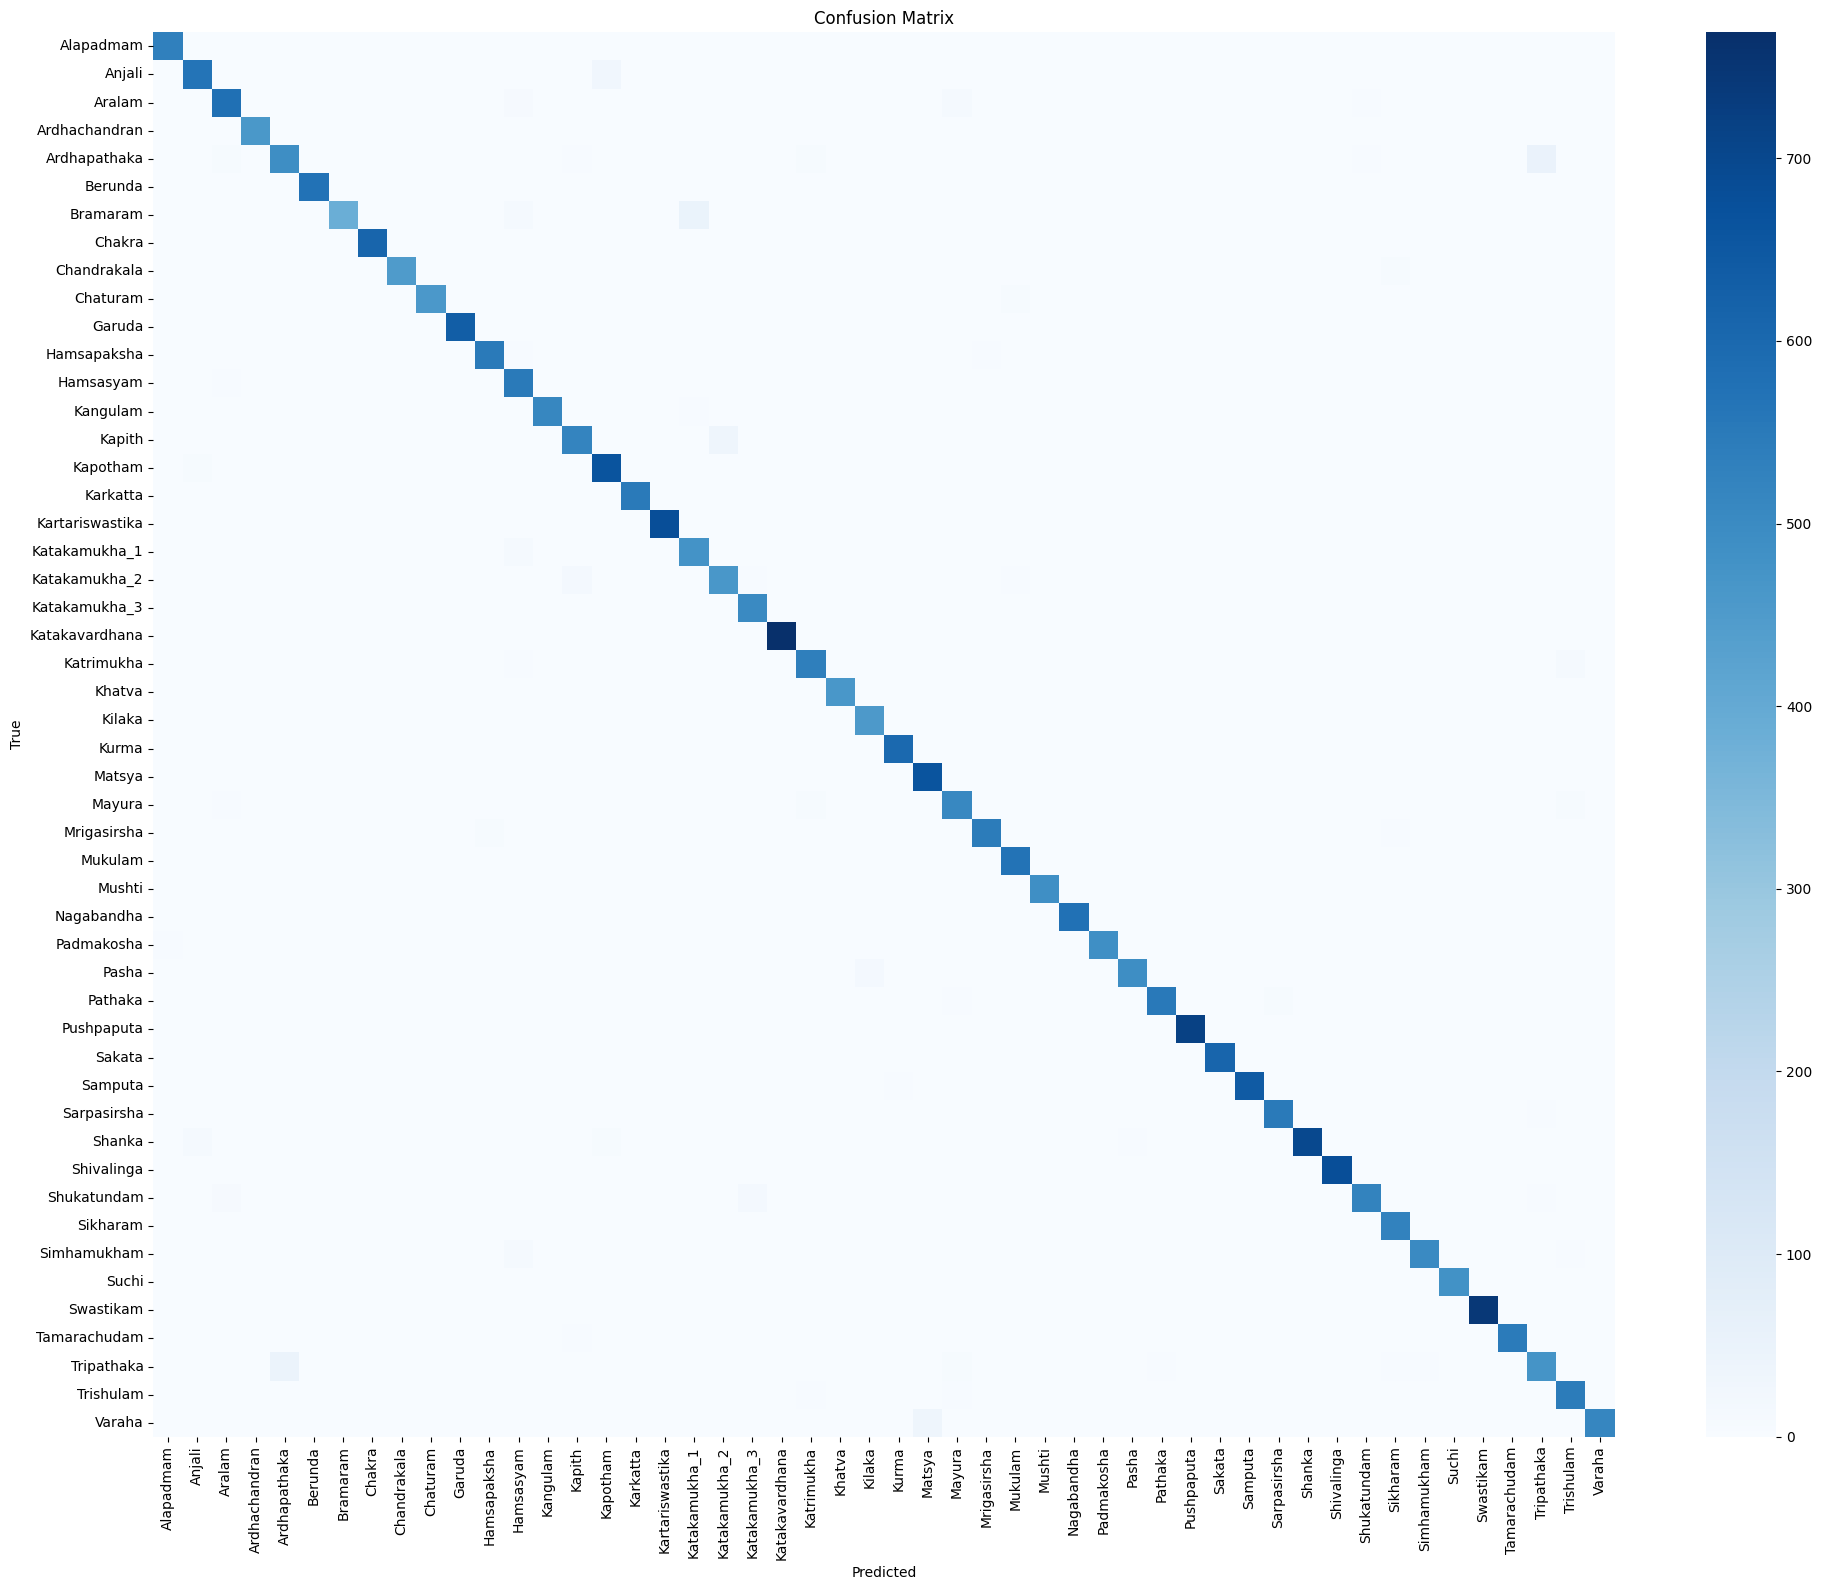


Per-class accuracy:

Alapadmam: 533/537 (99.26%)
Anjali: 565/593 (95.28%)
Aralam: 578/615 (93.98%)
Ardhachandran: 462/463 (99.78%)
Ardhapathaka: 491/577 (85.10%)
Berunda: 573/573 (100.00%)
Bramaram: 385/455 (84.62%)
Chakra: 610/610 (100.00%)
Chandrakala: 448/466 (96.14%)
Chaturam: 459/466 (98.50%)
Garuda: 633/633 (100.00%)
Hamsapaksha: 552/569 (97.01%)
Hamsasyam: 551/565 (97.52%)
Kangulam: 512/527 (97.15%)
Kapith: 520/558 (93.19%)
Kapotham: 661/669 (98.80%)
Karkatta: 550/550 (100.00%)
Kartariswastika: 679/681 (99.71%)
Katakamukha_1: 476/492 (96.75%)
Katakamukha_2: 463/488 (94.88%)
Katakamukha_3: 502/507 (99.01%)
Katakavardhana: 769/769 (100.00%)
Katrimukha: 535/564 (94.86%)
Khatva: 463/463 (100.00%)
Kilaka: 455/458 (99.34%)
Kurma: 600/602 (99.67%)
Matsya: 663/663 (100.00%)
Mayura: 508/534 (95.13%)
Mrigasirsha: 544/559 (97.32%)
Mukulam: 568/571 (99.47%)
Mushti: 489/490 (99.80%)
Nagabandha: 574/577 (99.48%)
Padmakosha: 487/495 (98.38%)
Pasha: 490/507 (96.65%)
Pathaka: 553/568 (97.36%)
P

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

eval_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    color_mode='grayscale',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

eval_class_names = eval_ds.class_names
print("Eval class names:")
print(eval_class_names)

y_true = np.concatenate([y.numpy() for _, y in eval_ds])

y_pred_probs = model.predict(eval_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

all_labels = list(range(len(eval_class_names)))

print("\nClassification Report:\n")
print(
    classification_report(
        y_true,
        y_pred,
        labels=all_labels,
        target_names=eval_class_names,
        digits=4,
        zero_division=0
    )
)

cm = confusion_matrix(y_true, y_pred, labels=all_labels)

plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=eval_class_names, yticklabels=eval_class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nPer-class accuracy:\n")
for i, class_name in enumerate(eval_class_names):
    total = cm[i].sum()
    correct = cm[i, i]
    acc = (correct / total) * 100 if total > 0 else 0
    print(f"{class_name}: {correct}/{total} ({acc:.2f}%)")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import files

files.download("/content/drive/MyDrive/mudra_mobilenetv2_outputs/mudra_mobilenetv2_final.keras")
files.download("/content/drive/MyDrive/mudra_mobilenetv2_outputs/class_names.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>